# `nklib` tutorial

This notebook teaches the refractive-index tools in `empylib.nklib`: tabulated files, oscillator models, effective-medium approximations, and material shortcuts. The core examples are fully offline and use the packaged `.nk` files shipped with the repository.

**Learning goals**

- load local optical-constant tables with `get_nkfile`
- understand when to use tabulated data, oscillator models, and blended extrapolation
- fit a synthetic spectrum with `fit_to_oscillator` and inspect the fitted parameters
- use EMT and VO2 utilities, then survey the offline material shortcut catalog

**Notebook design**

- every runnable cell calls the public `empylib` API directly
- parameter meanings are explained in markdown and in short inline comments
- outputs are inspected in the same notebook so you can see what each function returns
- the core path is offline-first; internet-backed examples live in clearly marked optional appendices

In [1]:
from pathlib import Path
import os
import sys

current = Path.cwd().resolve()
for candidate in (current, *current.parents):
    if (candidate / "empylib").exists() and (candidate / "docs").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the EMPI Lib repository root.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (7, 3)

import warnings

from scipy.integrate import IntegrationWarning

import empylib.nklib as nk
import empylib.waveoptics as wv

## Load a local `.nk` file and inspect the interpolated output

**Functions used**

- nk.get_nkfile

**Problem we are solving**

A common starting point is a tabulated material file. Here we load silica from the packaged database, interpolate it on a wavelength grid, and compare the interpolated `n + ik` output against the raw table.

**Parameter guide for this example**

- `wavelength`: wavelength grid in micrometers where you want the interpolated refractive index
- `MaterialName`: base name of the `.nk` file without the extension
- `get_from_local_path=True`: search inside `empylib/nk_files` instead of the current working directory
- `lam_units='um'`: declares the units of the wavelength grid you passed in

**Outputs to inspect**

- `n_sio2`: complex array `n + ik` evaluated on `wavelength`
- `nk_table`: original tabulated data as a DataFrame indexed by wavelength
- a quick plot showing the interpolated real and imaginary parts

,n,k
lambda,,
0.000790,0.99988,0.000011
0.000809,0.99987,0.000012
0.000829,0.99987,0.000013
0.000850,0.99986,0.000014
0.000870,0.99985,0.000016


Interpolated array shape: (250,)
First complex value: (1.5030413715+9.95894742554e-06j)


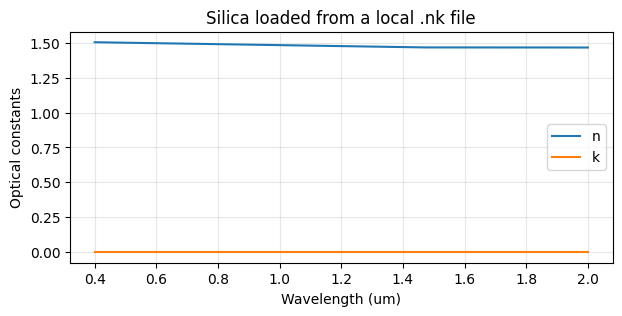

In [2]:
lam = np.linspace(0.40, 2.00, 250)

n_sio2, nk_table = nk.get_nkfile(
    lam,
    "sio2_Palik_Lemarchand2013",  # packaged file name without ".nk"
    get_from_local_path=True,      # read from empylib/nk_files
    lam_units="um",                # lam is already in micrometers
)

display(nk_table.head())
print("Interpolated array shape:", n_sio2.shape)
print("First complex value:", n_sio2[0])

fig, ax = plt.subplots()
ax.plot(lam, n_sio2.real, label="n")
ax.plot(lam, n_sio2.imag, label="k")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Optical constants")
ax.set_title("Silica loaded from a local .nk file")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The returned complex array always matches the wavelength grid you requested. The DataFrame is useful when you want to inspect the source table, its valid wavelength range, or reuse it for a custom interpolation workflow.

**Common pitfalls**

- Do not include the `.nk` extension in `MaterialName`
- If you set `get_from_local_path=False`, the function looks in the current working directory instead of the packaged database
- If you pass wavelengths outside the tabulated range, you should think explicitly about extrapolation behavior

**Try this next**

- Try a different packaged material such as `CaCO3_Palik` or `GSTa_Du2016`
- Pass wavelengths in nanometers and change `lam_units` to `'nm'`

## Blend tabulated data with a model outside a trusted range

**Functions used**

- nk.lorentz
- nk.blend_model

**Problem we are solving**

Sometimes you trust tabulated data only in a limited interval and want a smooth handoff to a model outside that interval. This example uses a Lorentz model as the outer behavior and the measured data in the middle.

**Parameter guide for this example**

- `nk_df`: DataFrame with `n` and `k` columns indexed by wavelength
- `nk_model`: model-predicted complex index on the same wavelength grid as `wavelength`
- `blend_low` and `blend_high`: smoothing windows near the lower and upper table edges
- `epsinf`, `wp`, `wn`, `gamma`: Lorentz parameters controlling high-frequency dielectric constant, strength, resonance, and damping

**Outputs to inspect**

- `lorentz_model`: a physically motivated model for the full wavelength span
- `blended_nk`: tabulated values inside the trusted range and model values outside it
- a plot comparing the pure model and the blended result

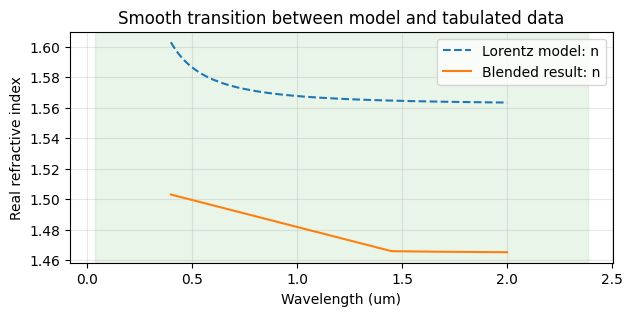

In [3]:
lower_edge = nk_table.index[int(0.25 * len(nk_table))]
upper_edge = nk_table.index[int(0.75 * len(nk_table))]
trusted_table = nk_table.loc[(nk_table.index >= lower_edge) & (nk_table.index <= upper_edge)]

lorentz_model = nk.lorentz(
    lam,
    epsinf=1.8,  # dielectric constant at very high energy
    wp=6.0,      # oscillator strength / plasma frequency in eV
    wn=7.5,      # resonance energy in eV
    gamma=0.8,   # damping in eV
)

blended_nk = nk.blend_model(
    lam,
    trusted_table,   # trusted n,k table in the middle of the spectrum
    lorentz_model,   # model used outside the tabulated interval
    blend_low=0.08,  # low-end smoothing window in micrometers
    blend_high=0.08, # high-end smoothing window in micrometers
)

fig, ax = plt.subplots()
ax.plot(lam, lorentz_model.real, "--", label="Lorentz model: n")
ax.plot(lam, blended_nk.real, label="Blended result: n")
ax.axvspan(trusted_table.index.min(), trusted_table.index.max(), color="tab:green", alpha=0.10)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real refractive index")
ax.set_title("Smooth transition between model and tabulated data")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

Inside the shaded region the result follows the table, while outside it follows the Lorentz model. The blend windows prevent a visible discontinuity at the handoff points.

**Common pitfalls**

- The DataFrame passed to `blend_model` must have `n` and `k` columns and a wavelength index
- Choose a model that is at least qualitatively compatible with the material outside the measured range
- If your blend windows are too wide, the model can distort part of the range you actually trust

**Try this next**

- Swap the Lorentz model for a `multi_oscillator` model
- Reduce `blend_low` and `blend_high` to see where the transition becomes abrupt

## Compare the individual oscillator families

**Functions used**

- nk.gaussian
- nk.tauc_lorentz
- nk.lorentz
- nk.drude

**Problem we are solving**

The oscillator utilities provide compact analytic models for different physical situations: bounded resonances, band-edge absorption, dielectric resonances, and free-carrier behavior. This section shows how each one is called.

**Parameter guide for this example**

- `A`, `Br`, `E0`: Gaussian amplitude, broadening, and center energy
- `A`, `C`, `E0`, `Eg`: Tauc-Lorentz amplitude, broadening, resonance energy, and bandgap
- `epsinf`, `wp`, `wn`, `gamma`: Lorentz dielectric background, strength, resonance, and damping
- `epsinf`, `wp`, `gamma`: Drude background, plasma frequency, and damping

**Outputs to inspect**

- four complex spectra that you can compare directly
- a plot of the real refractive index from each oscillator family

,gaussian_n,tauc_lorentz_n,lorentz_n,drude_n
Wavelength (um),,,,
0.450000,0.081732,1.117577,5.915803,0.083374
0.456164,0.098828,1.105557,5.643121,0.085283
0.462329,0.117765,1.094140,5.406166,0.087223
0.468493,0.138461,1.083288,5.200265,0.089192
0.474658,0.160807,1.072964,5.020588,0.091192


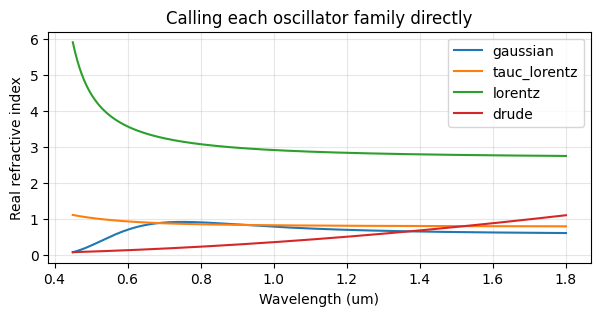

In [4]:
lam_model = np.linspace(0.45, 1.80, 220)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)

    n_gaussian = nk.gaussian(
        lam_model,
        A=1.1,   # absorption amplitude
        Br=0.30, # Gaussian broadening in eV
        E0=2.0,  # center energy in eV
    )

    n_tauc = nk.tauc_lorentz(
        lam_model,
        A=10.0,  # oscillator amplitude
        C=1.2,   # broadening in eV
        E0=4.0,  # resonance energy in eV
        Eg=1.8,  # bandgap in eV
    )

n_lorentz = nk.lorentz(
    lam_model,
    epsinf=1.0,
    wp=7.5,
    wn=3.0,
    gamma=0.25,
)

n_drude = nk.drude(
    lam_model,
    epsinf=1.0,
    wp=5.5,
    gamma=0.20,
)

oscillator_preview = pd.DataFrame(
    {
        "gaussian_n": n_gaussian.real,
        "tauc_lorentz_n": n_tauc.real,
        "lorentz_n": n_lorentz.real,
        "drude_n": n_drude.real,
    },
    index=lam_model,
)
oscillator_preview.index.name = "Wavelength (um)"
display(oscillator_preview.head())

fig, ax = plt.subplots()
ax.plot(lam_model, n_gaussian.real, label="gaussian")
ax.plot(lam_model, n_tauc.real, label="tauc_lorentz")
ax.plot(lam_model, n_lorentz.real, label="lorentz")
ax.plot(lam_model, n_drude.real, label="drude")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real refractive index")
ax.set_title("Calling each oscillator family directly")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The shapes are intentionally different. Gaussian and Tauc-Lorentz are useful for bounded absorption features, while Lorentz and Drude are the classic dielectric and free-carrier building blocks.

**Common pitfalls**

- Oscillator parameters are in electron-volts, not micrometers
- The Gaussian and Tauc-Lorentz models reconstruct the real part through a Kramers-Kronig step, so extreme parameters can become numerically stiff
- A good-looking `n` curve does not guarantee the `k` curve is physically meaningful; inspect both when fitting real data

**Try this next**

- Plot the imaginary parts as well to see where absorption is concentrated
- Increase `gamma` in the Lorentz or Drude model to broaden the response

## Combine oscillators and fit them to a target spectrum

**Functions used**

- nk.multi_oscillator
- nk.fit_to_oscillator

**Problem we are solving**

Real materials often need more than one oscillator term. Here we build a synthetic target from a known oscillator dictionary, then recover the parameters with `fit_to_oscillator`.

**Parameter guide for this example**

- `oscillator_dict`: nested dictionary whose keys are oscillator family names
- `n_data` and `k_data`: measured or synthetic real and imaginary parts to fit
- `bounds`: optional parameter limits; omitted here to use the defaults
- `x_units='um'`: declares the wavelength units used in the fit input

**Outputs to inspect**

- `target_nk`: synthetic target spectrum
- `fitted_oscillator`: dictionary with recovered parameters
- `result`: SciPy optimization result with convergence information

Optimization succeeded: True
Recovered oscillator dictionary:


model1    {'type': 'lorentz', 'epsinf': 0.97670815154992...
model2    {'type': 'gaussian', 'A': 1.6388092039674052e-...
dtype: object

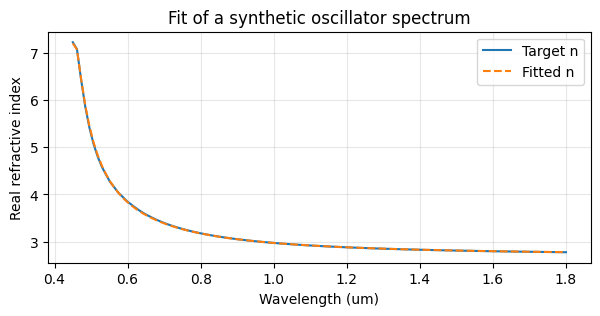

In [2]:
lam_fit = np.linspace(0.45, 1.80, 120)

target_oscillator = {
    "model1": {
        "type": "lorentz",
        "epsinf": 1.0,
        "wp": 7.0,
        "wn": 2.8,
        "gamma": 0.22,
    },
    "model2": {
        "type": "gaussian",
        "A": 0.4,
        "Br": 0.18,
        "E0": 2.3,
    },
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)
    target_nk = nk.multi_oscillator(lam_fit, target_oscillator)

initial_guess = {
    "model1": {
        "type": "lorentz",
        "epsinf": 1.2,
        "wp": 6.5,
        "wn": 2.7,
        "gamma": 0.30,
    },
    "model2": {
        "type": "gaussian",
        "A": 0.3,
        "Br": 0.25,
        "E0": 2.1,
    },
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)
    fitted_oscillator, result = nk.fit_to_oscillator(
        lam_fit,
        [target_nk.real, target_nk.imag],   # n and k data
        initial_guess,    # initial parameter dictionary
        x_units="um",     # wavelength unit used by lam_fit
    )
    fitted_nk = nk.multi_oscillator(lam_fit, fitted_oscillator)

print("Optimization succeeded:", result.success)
print("Recovered oscillator dictionary:")
display(pd.Series({key: str(value) for key, value in fitted_oscillator.items()}))

fig, ax = plt.subplots()
ax.plot(lam_fit, target_nk.real, label="Target n")
ax.plot(lam_fit, fitted_nk.real, "--", label="Fitted n")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real refractive index")
ax.set_title("Fit of a synthetic oscillator spectrum")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

A good fit means the dashed curve tracks the target closely and `result.success` is `True`. The fitted dictionary can be reused directly with `multi_oscillator` or as an extrapolation model elsewhere in the library.

**Common pitfalls**

- Bad initial guesses can trap the optimizer in poor local minima
- If a fit looks unstable, add bounds or reduce the number of free oscillator terms
- Always inspect both `n` and `k` when you fit measured data

**Try this next**

- Fit only one oscillator family to see where the model becomes too rigid
- Pass custom `weights` if matching the imaginary part is more important than the real part

### Fit custom observables with fixed extra arguments

If your measurements are not direct n/k data, you can pass a custom forward model through `y_eval`. In this example the unknown material is a single thin film measured on several samples with known thickness, so the optimizer still fits only the oscillator parameters while the film geometry is held fixed through `args`.

**Function pattern to notice**

- `y_eval(lam, nk, substrate_n, thicknesses)` receives the fitted complex index as its second argument
- every item returned by `y_eval` must have a matching target block in `y_data`
- fixed extra inputs stay in `args`, in the same positional order expected by `y_eval`

In [ ]:
def multilayer_rt_eval(lam, nk, substrate_n, thicknesses):
    outputs = []
    for thickness in np.asarray(thicknesses, dtype=float):
        R, T, _, _ = wv.multilayer(
            lam,
            N_layers=[nk],
            thickness=[thickness],
            N_above=1.00,
            N_below=substrate_n,
        )
        outputs.extend([R, T])
    return outputs

known_thicknesses = np.array([0.08, 0.14, 0.22])
target_rt_fixed = multilayer_rt_eval(lam_fit, target_nk, 1.52, known_thicknesses)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)
    fitted_oscillator_fixed, result_fixed = nk.fit_to_oscillator(
        lam_fit,
        target_rt_fixed,
        initial_guess,
        y_eval=multilayer_rt_eval,
        args=(1.52, known_thicknesses),
        x_units="um",
    )
    fitted_nk_fixed = nk.multi_oscillator(lam_fit, fitted_oscillator_fixed)

fitted_rt_fixed = multilayer_rt_eval(lam_fit, fitted_nk_fixed, 1.52, known_thicknesses)

print("Custom-fit with fixed film geometry succeeded:", result_fixed.success)

fig, ax = plt.subplots()
ax.plot(lam_fit, target_rt_fixed[0], label="Target R, film 1")
ax.plot(lam_fit, fitted_rt_fixed[0], "--", label="Fitted R, film 1")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Reflectance")
ax.set_title("Fit using fixed extra arguments in args")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Fit extra model parameters together with the oscillator

Sometimes part of the forward model is also unknown. Here the same multilayer evaluator is used, but the three film thicknesses are treated as fitted parameters through `fit_extra_params` while the substrate index stays fixed in `args`.

**What changes compared with the previous example**

- `args=(1.52,)` keeps only the fixed substrate input positional
- `fit_extra_params` appends `thicknesses` to the optimizer state and feeds it back into `y_eval` by keyword name
- the recovered values are available in `result.fit_extra_params`

In [ ]:
true_thicknesses = np.array([0.08, 0.14, 0.22])
target_rt_unknown = multilayer_rt_eval(lam_fit, target_nk, 1.52, true_thicknesses)

fit_extra_specs = {
    "thicknesses": {
        "init": [0.06, 0.11, 0.18],
        "bounds": (0.03, 0.30),
        "shape": (3,),
    }
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", IntegrationWarning)
    fitted_oscillator_extra, result_extra = nk.fit_to_oscillator(
        lam_fit,
        target_rt_unknown,
        initial_guess,
        y_eval=multilayer_rt_eval,
        args=(1.52,),
        fit_extra_params=fit_extra_specs,
        x_units="um",
    )
    fitted_nk_extra = nk.multi_oscillator(lam_fit, fitted_oscillator_extra)

recovered_thicknesses = result_extra.fit_extra_params["thicknesses"]
fitted_rt_unknown = multilayer_rt_eval(lam_fit, fitted_nk_extra, 1.52, recovered_thicknesses)

print("Joint oscillator + thickness fit succeeded:", result_extra.success)
display(
    pd.DataFrame(
        {
            "true_thickness_um": true_thicknesses,
            "recovered_thickness_um": recovered_thicknesses,
        },
        index=["film 1", "film 2", "film 3"],
    )
)

fig, ax = plt.subplots()
ax.plot(lam_fit, target_rt_unknown[0], label="Target R, film 1")
ax.plot(lam_fit, fitted_rt_unknown[0], "--", label="Fitted R, film 1")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Reflectance")
ax.set_title("Fit using fit_extra_params for thickness")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Use effective-medium utilities and Kramers-Kronig reconstruction

**Functions used**

- nk.emt_multilayer_sphere
- nk.emt_brugg
- nk.eps_real_kkr

**Problem we are solving**

The effective-medium tools help when you want a compact surrogate for a layered particle or a composite medium. `eps_real_kkr` is useful when you know an absorption profile and need the dispersive real part implied by causality.

**Parameter guide for this example**

- `D`: shell diameters for `emt_multilayer_sphere`
- `Np`: refractive index of each shell, from inner to outer layer
- `fv_1`, `nk_1`, `nk_2`: volume fraction and refractive indices for the Bruggeman mixture
- `eps_imag`: imaginary dielectric component, given here as an array on the same wavelength grid

**Outputs to inspect**

- `n_eff_layered`: effective index of a multilayer sphere
- `n_eff_mix`: Bruggeman effective index for a binary composite
- `eps_real`: reconstructed real dielectric function from the chosen imaginary spectrum

Layered-sphere effective index: (1.98527237591+0.00929610580344j)
Bruggeman effective index: (1.70660430306+0.0208343684091j)


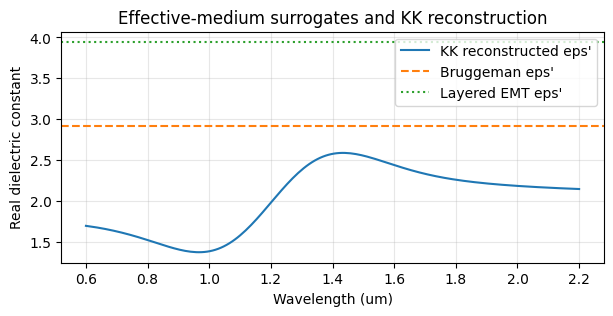

In [6]:
lam_emt = np.linspace(0.60, 2.20, 180)

n_eff_layered = nk.emt_multilayer_sphere(
    [0.08, 0.10],                   # diameters of the inner core and outer shell
    [1.70 + 0.00j, 2.30 + 0.02j],   # refractive index of each layer
)

n_eff_mix = nk.emt_brugg(
    0.25,           # inclusion volume fraction
    2.4 + 0.10j,    # inclusion refractive index
    1.5 + 0.00j,    # host refractive index
)

eps_imag = np.exp(-((lam_emt - 1.20) / 0.25) ** 2)
eps_real = nk.eps_real_kkr(
    lam_emt,
    eps_imag,  # imaginary dielectric spectrum sampled on lam_emt
    eps_inf=1.8,
)

print("Layered-sphere effective index:", n_eff_layered)
print("Bruggeman effective index:", n_eff_mix)

fig, ax = plt.subplots()
ax.plot(lam_emt, eps_real, label="KK reconstructed eps'")
ax.axhline(np.real(n_eff_mix**2), color="tab:orange", linestyle="--", label="Bruggeman eps'")
ax.axhline(np.real(n_eff_layered**2), color="tab:green", linestyle=":", label="Layered EMT eps'")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real dielectric constant")
ax.set_title("Effective-medium surrogates and KK reconstruction")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The EMT functions return compact effective indices that you can feed into wave-optics or radiative-transfer models. The Kramers-Kronig reconstruction links absorption and dispersion, so a peak in the imaginary part creates a dispersive feature in the real part.

**Common pitfalls**

- EMT is an approximation; it is most useful when the inhomogeneity is subwavelength relative to the optical problem
- For `eps_real_kkr`, the imaginary spectrum must be sampled on the same wavelength grid you pass in
- If you use a callable imaginary part instead of an array, you should think carefully about the integration limits

**Try this next**

- Change the filling fraction in `emt_brugg` and observe how fast the effective index moves toward the inclusion material
- Use a broader or narrower `eps_imag` peak to see the dispersion change in `eps_real_kkr`

## Temperature-dependent VO2 response

**Functions used**

- nk.VO2

**Problem we are solving**

VO2 is a useful example of a phase-change material with a temperature-controlled optical response. This function blends the cold and hot optical constants internally and gives you a single temperature-dependent spectrum.

**Parameter guide for this example**

- `wavelength`: wavelength grid in micrometers
- `T`: material temperature in Celsius
- `film`: selects which tabulated VO2 film from the packaged dataset is used

**Outputs to inspect**

- `n_cold` and `n_hot`: complex spectra at two temperatures
- a plot of the real refractive index change across the transition

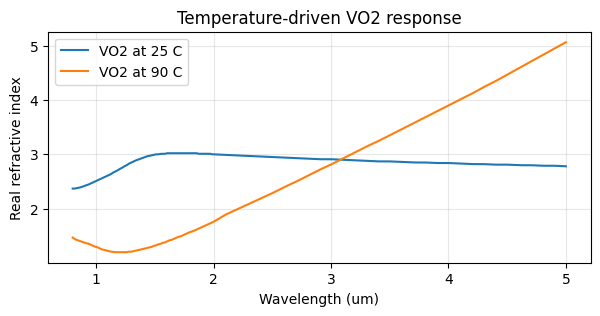

In [7]:
lam_vo2 = np.linspace(0.80, 5.00, 220)

n_cold = nk.VO2(
    lam_vo2,
    T=25,   # temperature in Celsius
    film=2, # packaged film choice from the library
)

n_hot = nk.VO2(
    lam_vo2,
    T=90,
    film=2,
)

fig, ax = plt.subplots()
ax.plot(lam_vo2, n_cold.real, label="VO2 at 25 C")
ax.plot(lam_vo2, n_hot.real, label="VO2 at 90 C")
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real refractive index")
ax.set_title("Temperature-driven VO2 response")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

The separation between the cold and hot curves is the optical signature of the phase transition. You can use these outputs anywhere else in the library that expects a wavelength-dependent refractive index.

**Common pitfalls**

- Temperatures are in Celsius, not Kelvin
- The output depends on the selected `film` dataset, so keep the film choice consistent when comparing cases

**Try this next**

- Evaluate more temperatures between 25 C and 90 C to map the transition curve
- Feed the cold and hot spectra into `waveoptics.multilayer` to study a thermochromic coating

## Offline material shortcut catalog

**Functions used**

- nk.CaCO3
- nk.BaSO4
- nk.BiVO4_mono_a
- nk.BiVO4_mono_b
- nk.BiVO4_mono_c
- nk.BiVO4
- nk.Cu2O
- nk.MgO
- nk.GSTa
- nk.GSTc
- nk.VO2M
- nk.VO2R
- nk.gold
- nk.silver
- nk.Cu
- nk.Al
- nk.HDPE
- nk.PDMS
- nk.PVDF
- nk.H2O

**Problem we are solving**

Many day-to-day workflows do not need a file name or a full web lookup. The shortcut functions wrap the common packaged materials so you can request a refractive-index spectrum with one explicit call per material.

**Parameter guide for this example**

- `lam_short`: a short wavelength grid used here only to prove the functions run and return complex values
- each shortcut takes the same first argument: the wavelength grid in micrometers
- `VO2M` and `VO2R` also accept a `film` selector if you want a different packaged VO2 dataset

**Outputs to inspect**

- `shortcut_preview`: one representative complex value per material shortcut
- a compact plot comparing a few real refractive-index curves

CaCO3           1.670253+0.000000j
BaSO4           1.652435+0.000000j
BiVO4_mono_a    2.804229+0.001792j
BiVO4_mono_b    2.553877+0.001128j
BiVO4_mono_c    2.804229+0.001792j
BiVO4           2.720778+0.001570j
Cu2O            2.739000+0.000000j
MgO             1.725408+0.000000j
GSTa            4.405812+0.009374j
GSTc            6.437489+0.156297j
VO2M            2.420000+0.850000j
VO2R            1.370000+1.070000j
gold            0.135800+5.825000j
silver          0.113329+5.952647j
Cu              0.068092+5.966300j
Al              2.111000+8.219682j
HDPE            1.467081+0.000012j
PDMS            1.399000+0.000000j
PVDF            1.388456+0.000000j
H2O             1.328000+0.000000j
Name: representative n + ik, dtype: complex128

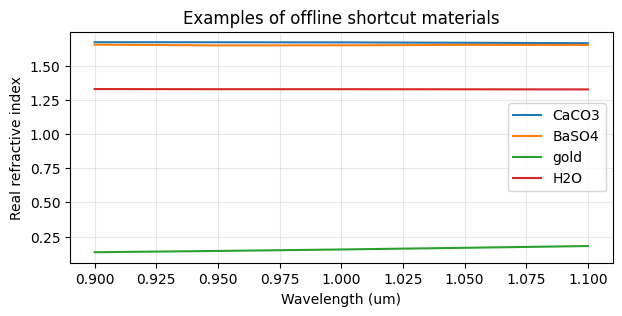

In [8]:
lam_short = np.linspace(0.90, 1.10, 5)
lam_gst = np.linspace(2.70, 3.00, 5)

shortcut_catalog = {
    "CaCO3": nk.CaCO3(lam_short),
    "BaSO4": nk.BaSO4(lam_short),
    "BiVO4_mono_a": nk.BiVO4_mono_a(lam_short),
    "BiVO4_mono_b": nk.BiVO4_mono_b(lam_short),
    "BiVO4_mono_c": nk.BiVO4_mono_c(lam_short),
    "BiVO4": nk.BiVO4(lam_short),
    "Cu2O": nk.Cu2O(lam_short),
    "MgO": nk.MgO(lam_short),
    "GSTa": nk.GSTa(lam_gst),
    "GSTc": nk.GSTc(lam_gst),
    "VO2M": nk.VO2M(lam_short, film=2),
    "VO2R": nk.VO2R(lam_short, film=2),
    "gold": nk.gold(lam_short),
    "silver": nk.silver(lam_short),
    "Cu": nk.Cu(lam_short),
    "Al": nk.Al(lam_short),
    "HDPE": nk.HDPE(lam_short),
    "PDMS": nk.PDMS(lam_short),
    "PVDF": nk.PVDF(lam_short),
    "H2O": nk.H2O(lam_short),
}

shortcut_preview = pd.Series(
    {name: complex(np.atleast_1d(values)[0]) for name, values in shortcut_catalog.items()},
    name="representative n + ik",
)
display(shortcut_preview)

fig, ax = plt.subplots()
for label in ("CaCO3", "BaSO4", "gold", "H2O"):
    ax.plot(lam_short, np.real(shortcut_catalog[label]), label=label)
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Real refractive index")
ax.set_title("Examples of offline shortcut materials")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

**How to read the result**

Each shortcut returns the same kind of complex spectrum as `get_nkfile`, but with a simpler entry point. This is useful when you already know you want one of the packaged materials.

**Common pitfalls**

- Shortcut functions are convenient, but you should still check the valid wavelength range of the underlying data if you work near the edges
- For VO2 the shortcut pair `VO2M` and `VO2R` represent the cold and hot endpoint data, while `VO2` mixes them continuously with temperature

**Try this next**

- Pick a few shortcuts and compare their imaginary parts to identify which ones are absorptive in your band of interest
- Use these shortcut outputs directly in `miescattering.scatter_efficiency` or `waveoptics.multilayer`

## Optional Appendix: Online material lookup examples

These functions require internet access because they pull data from the refractiveindex.info database. Keep them out of your default offline workflow, but use them when you need a material that is not bundled locally.

In [9]:
lam = np.linspace(0.40, 1.60, 100)

ri_table = nk.ri_info_data(
    "main",          # shelf in refractiveindex.info
    "SiO2",          # material name (book)
    "Franta-25C",    # page / dataset label
)

n_web, ri_table_interp = nk.get_ri_info(
    lam,
    "main",
    "SiO2",
    "Franta-25C",
)

n_sio2 = nk.SiO2(lam)
n_silica = nk.Silica(lam)
n_baf2 = nk.BaF2(lam)
n_tio2 = nk.TiO2(lam)
n_zno = nk.ZnO(lam)
n_al2o3 = nk.Al2O3(lam)
n_zns = nk.ZnS(lam)
n_si = nk.Si(lam)
n_mg = nk.Mg(lam)
n_pmma = nk.PMMA(lam)

display(ri_table.head())

,n,k
wavelength,,
0.027504,0.933043,0.094680
0.027568,0.932937,0.094970
0.027631,0.932830,0.095260
0.027695,0.932722,0.095549
0.027759,0.932614,0.095837
